#  **DIGITAL MARKETING CAMPAIN ANALYSIS**






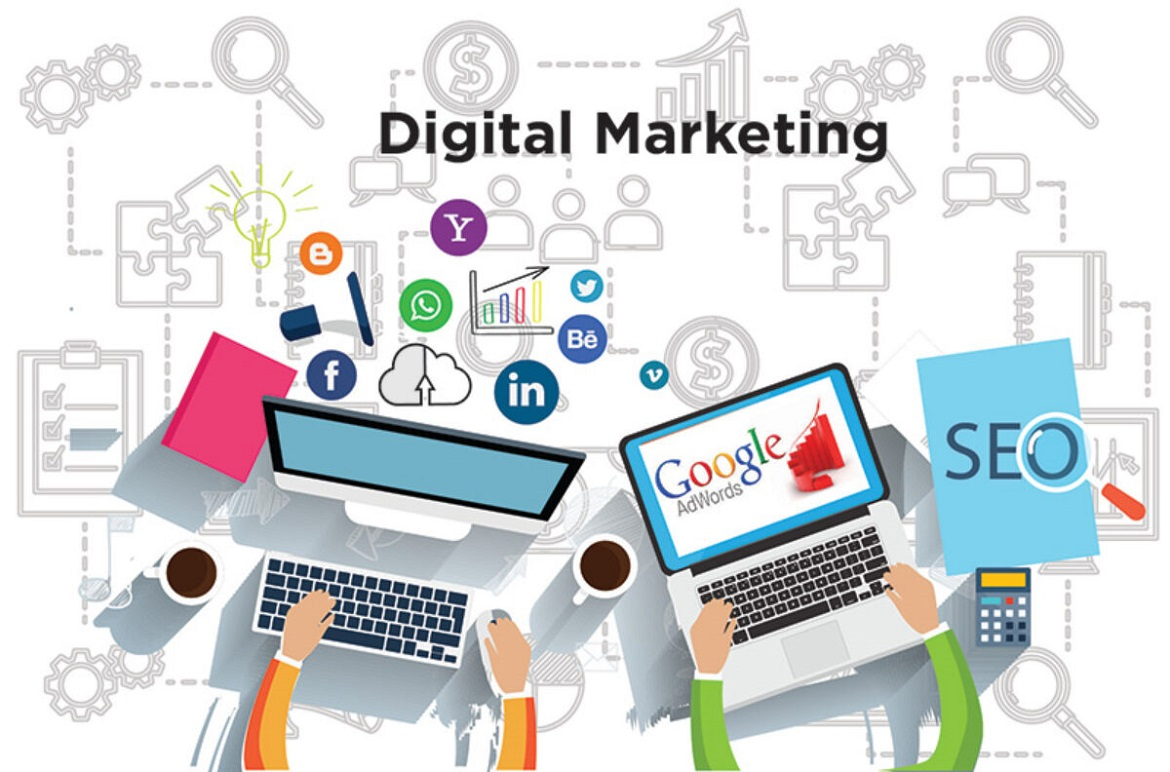

### **PROJECT CONTEXT**

In digital marketing, customers do not generate equal value.
Some campaigns lead to profitable conversions, while others result in unnecessary advertising costs.

Therefore, evaluating performance based only on traditional metrics such as conversion rate or cost per acquisition is not sufficient for making optimal business decisions.

### **OBJRCTIVE**

This project aims to develop a data-driven framework to optimize advertising decisions by:

Estimating the probability of customer conversion
Translating model outputs into real-world financial impact
Maximizing expected return from marketing activities
 Methodology

Instead of focusing solely on predictive accuracy, this project emphasizes business value through the following steps:

Building a classification model to predict conversion probability
Calibrating predicted probabilities to better reflect real-world outcomes
Estimating Customer Lifetime Value (LTV) for each customer
Computing Expected Value (EV) as a unified decision metric
### **DECISION FRAMEWORK**

All marketing decisions are based on Expected Value:

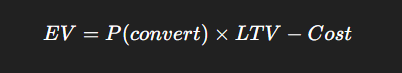



If EV > 0 → the customer is considered profitable and should be targeted

If EV < 0 → the customer is not profitable and should be excluded
### **EXPECTED OUTCOME**

This framework enables more efficient allocation of marketing budget by prioritizing high-value customers and eliminating unprofitable segments, ultimately improving overall campaign profitability.

---

### Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

Load Dataset

Link Dataset:
https://www.kaggle.com/code/devraai/digital-marketing-campaign-analysis-and-prediction/notebook

In [ ]:
file_path = '/content/marketing_campaign_ad.csv'
df = pd.read_csv(file_path)
display(df.head())

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


**Information Data**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Gender             8000 non-null   object 
 3   Income             8000 non-null   int64  
 4   CampaignChannel    8000 non-null   object 
 5   CampaignType       8000 non-null   object 
 6   AdSpend            8000 non-null   float64
 7   ClickThroughRate   8000 non-null   float64
 8   ConversionRate     8000 non-null   float64
 9   WebsiteVisits      8000 non-null   int64  
 10  PagesPerVisit      8000 non-null   float64
 11  TimeOnSite         8000 non-null   float64
 12  SocialShares       8000 non-null   int64  
 13  EmailOpens         8000 non-null   int64  
 14  EmailClicks        8000 non-null   int64  
 15  PreviousPurchases  8000 non-null   int64  
 16  LoyaltyPoints      8000 

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


## **DATA TYPE**

In [ ]:
df = df.drop(columns=['CustomerID'])
df['Conversion'] = df['Conversion'].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                8000 non-null   int64   
 1   Gender             8000 non-null   object  
 2   Income             8000 non-null   int64   
 3   CampaignChannel    8000 non-null   object  
 4   CampaignType       8000 non-null   object  
 5   AdSpend            8000 non-null   float64 
 6   ClickThroughRate   8000 non-null   float64 
 7   ConversionRate     8000 non-null   float64 
 8   WebsiteVisits      8000 non-null   int64   
 9   PagesPerVisit      8000 non-null   float64 
 10  TimeOnSite         8000 non-null   float64 
 11  SocialShares       8000 non-null   int64   
 12  EmailOpens         8000 non-null   int64   
 13  EmailClicks        8000 non-null   int64   
 14  PreviousPurchases  8000 non-null   int64   
 15  LoyaltyPoints      8000 non-null   int64   
 16  Conver

**Unique Data**

In [ ]:
cat_cols = ['CampaignChannel', 'CampaignType', 'Gender']

for col in cat_cols:
    print(f"\n Column: {col}")
    print("-" * 30)


    print("Unique values:")
    print(df[col].unique())

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False))


    print("\nValues with leading/trailing spaces:")
    print(df[df[col].str.strip() != df[col]][col])


 Column: CampaignChannel
------------------------------
Unique values:
['Social Media' 'Email' 'PPC' 'Referral' 'SEO']

Value counts:
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignChannel, dtype: object)

 Column: CampaignType
------------------------------
Unique values:
['Awareness' 'Retention' 'Conversion' 'Consideration']

Value counts:
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignType, dtype: object)

 Column: Gender
------------------------------
Unique values:
['Female' 'Male']

Value counts:
Gender
Female    4839
Male      3161
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: Gender, dtype: object)


## **HANDLE MISSING VALUES**

In [ ]:
df.isnull().sum()
df = df.dropna()

## **REMOVE DUPLICATES**

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

## **OUTLIERS**

In [ ]:
num_cols = [
    'Income',
    'AdSpend',
    'WebsiteVisits',
    'TimeOnSite',
    'PagesPerVisit',
    'PreviousPurchases',
    'LoyaltyPoints'
]

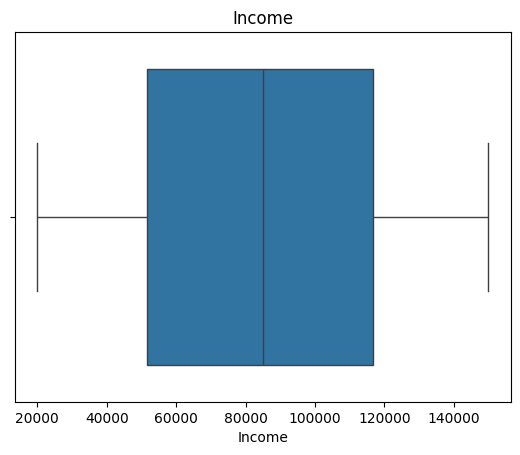

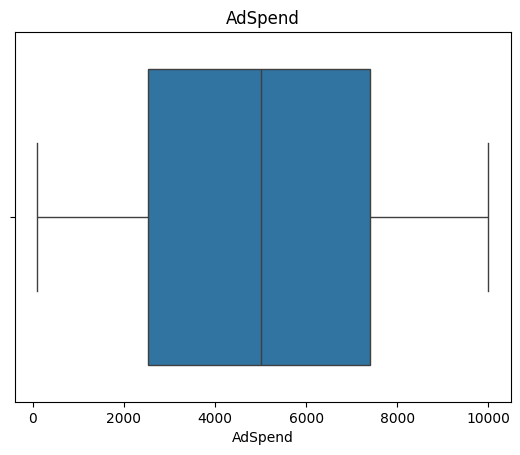

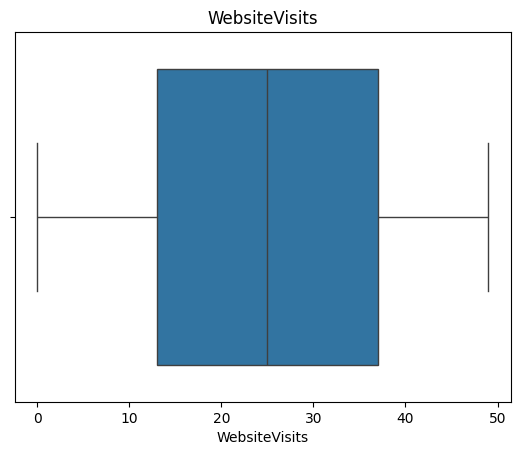

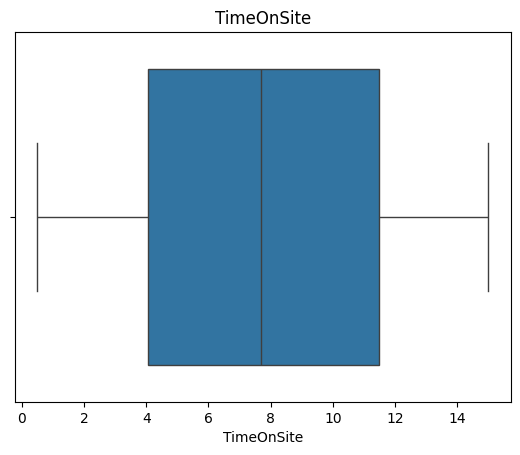

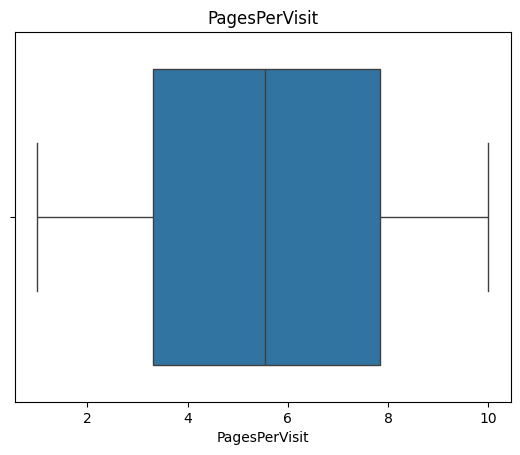

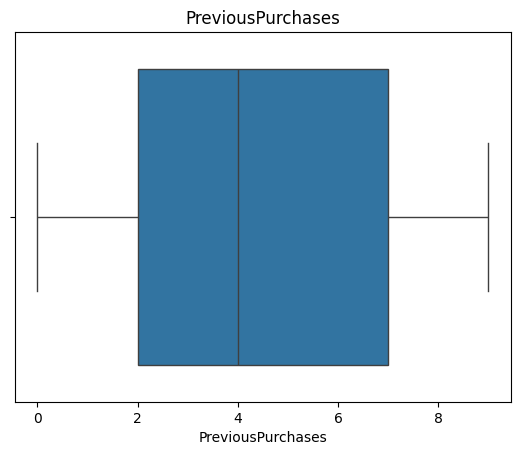

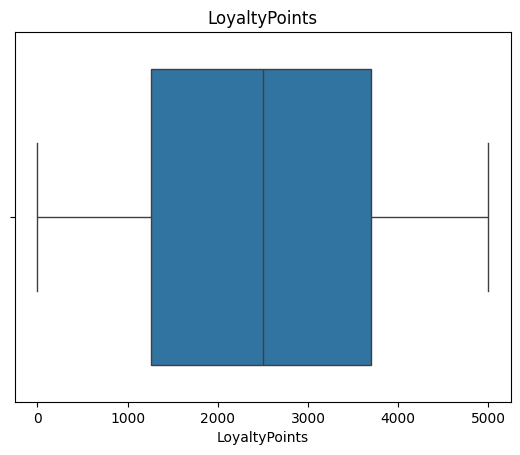

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

The selected numerical features (Income, AdSpend, WebsiteVisits, TimeOnSite, PagesPerVisit, PreviousPurchases, and LoyaltyPoints) do not exhibit significant outliers, indicating a relatively stable distribution without extreme values that could distort model training

In [ ]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] < lower) | (df[col] > upper)]
    find_outliers('Income')

## EDA (Exploratory Data Analysis)

**Conversion**

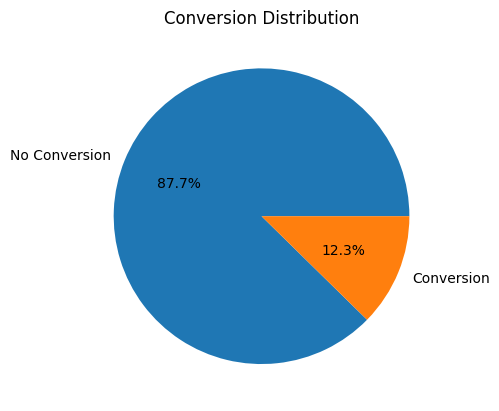

In [ ]:
conversion_counts = df['Conversion'].value_counts()
labels = ['No Conversion', 'Conversion']
plt.figure()
plt.pie(
    conversion_counts,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title('Conversion Distribution')
plt.show()

**Gender**

/tmp/ipykernel_316/4073436745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Conversion', data=df, ax=ax2, palette='pastel')


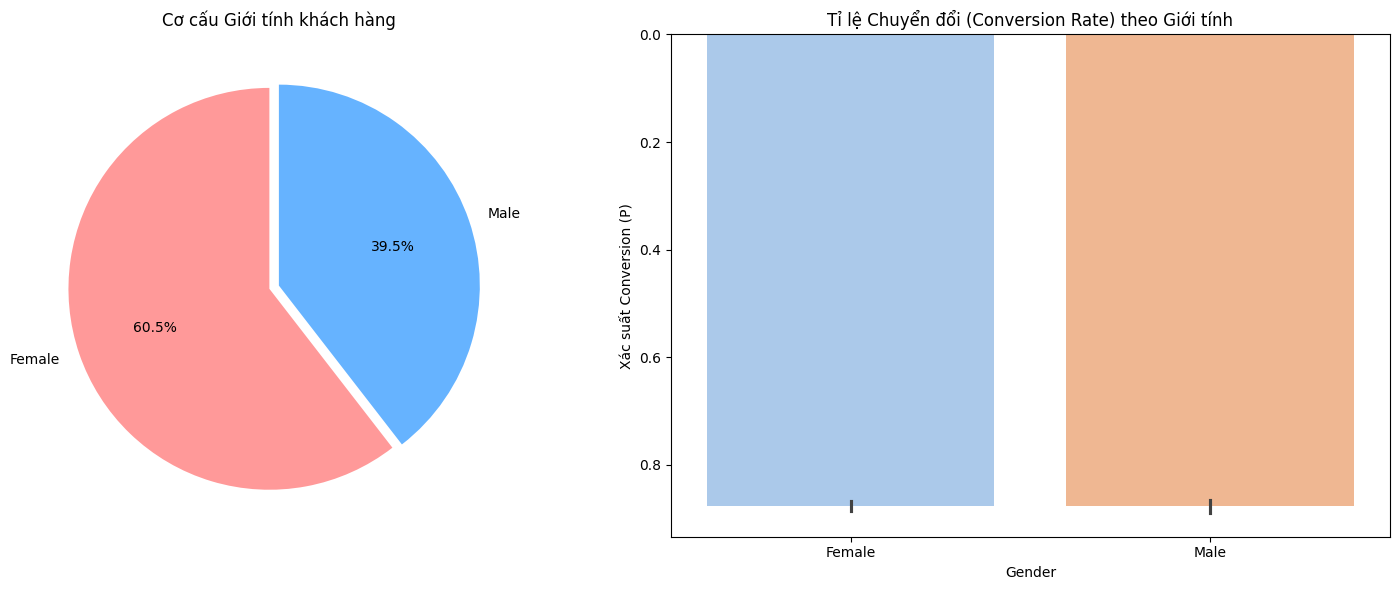

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
gender_counts = df['Gender'].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
ax1.set_title('Cơ cấu Giới tính khách hàng')
sns.barplot(x='Gender', y='Conversion', data=df, ax=ax2, palette='pastel')
ax2.set_title('Tỉ lệ Chuyển đổi (Conversion Rate) theo Giới tính')
ax2.set_ylabel('Xác suất Conversion (P)')
plt.tight_layout()
plt.show()

**Age**

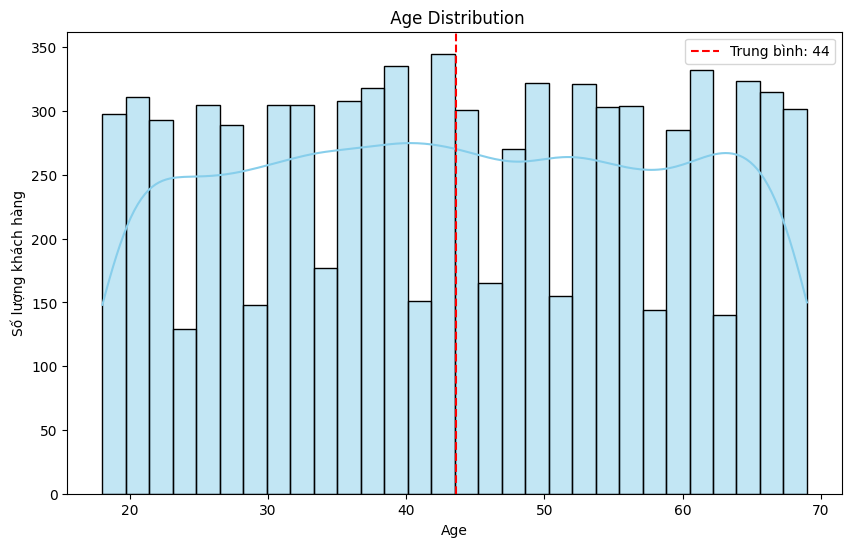

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Age'].mean():.0f}")
plt.title(' Age Distribution')
plt.xlabel('Age')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

AGE

<Axes: xlabel='Age', ylabel='Density'>

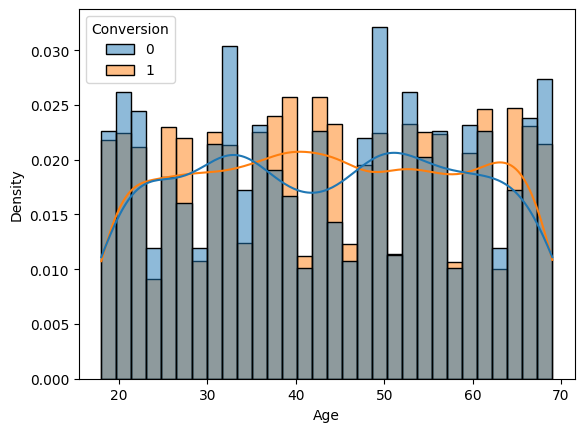

In [ ]:
sns.histplot(
    data=df,
    x="Age",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

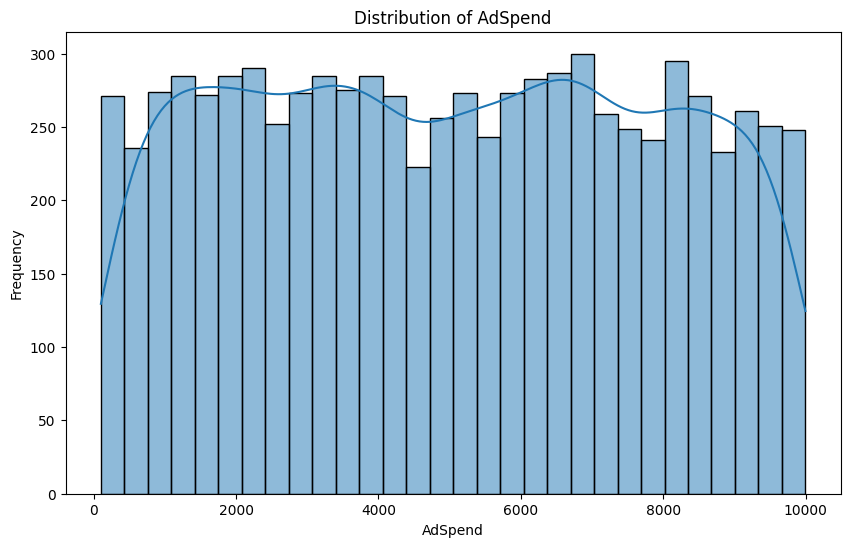

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='AdSpend',
    bins=30,
    kde=True
)

plt.title('Distribution of AdSpend')
plt.xlabel('AdSpend')
plt.ylabel('Frequency')

plt.show()

<Axes: xlabel='AdSpend', ylabel='Density'>

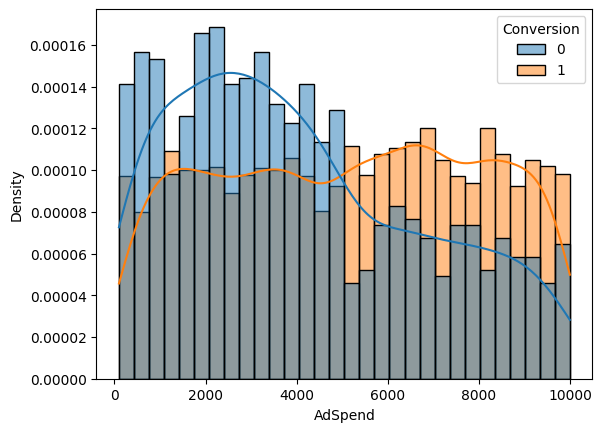

In [ ]:
sns.histplot(
    data=df,
    x="AdSpend",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

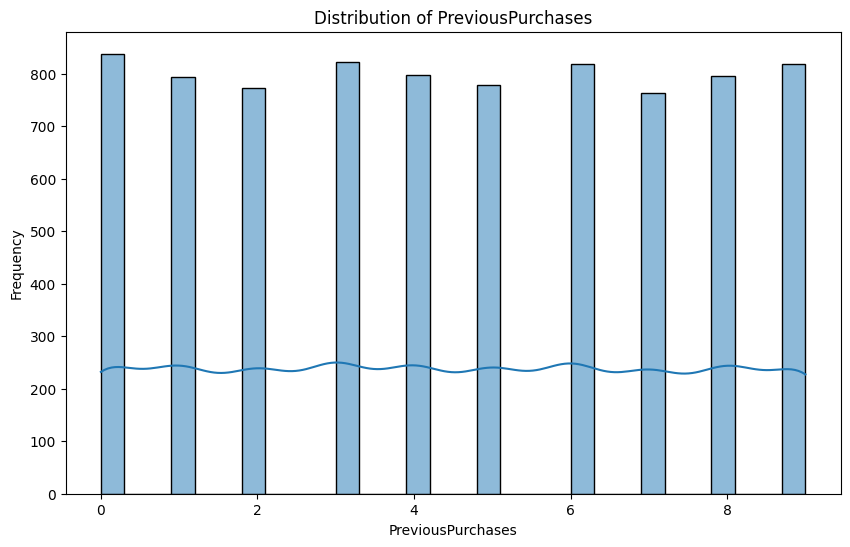

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='PreviousPurchases',
    bins=30,
    kde=True
)

plt.title('Distribution of PreviousPurchases')
plt.xlabel('PreviousPurchases')
plt.ylabel('Frequency')

plt.show()

<Axes: xlabel='PreviousPurchases', ylabel='Density'>

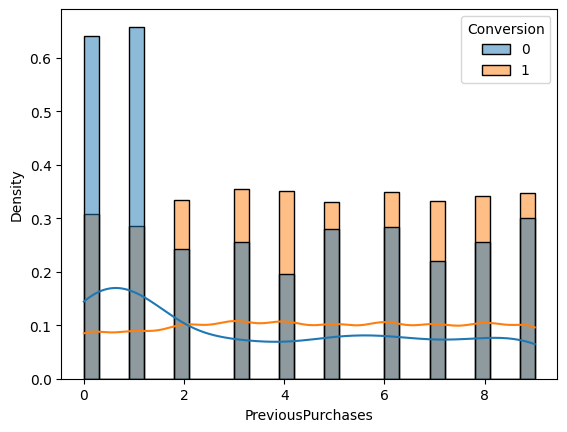

In [ ]:
sns.histplot(
    data=df,
    x="PreviousPurchases",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)



**Income**



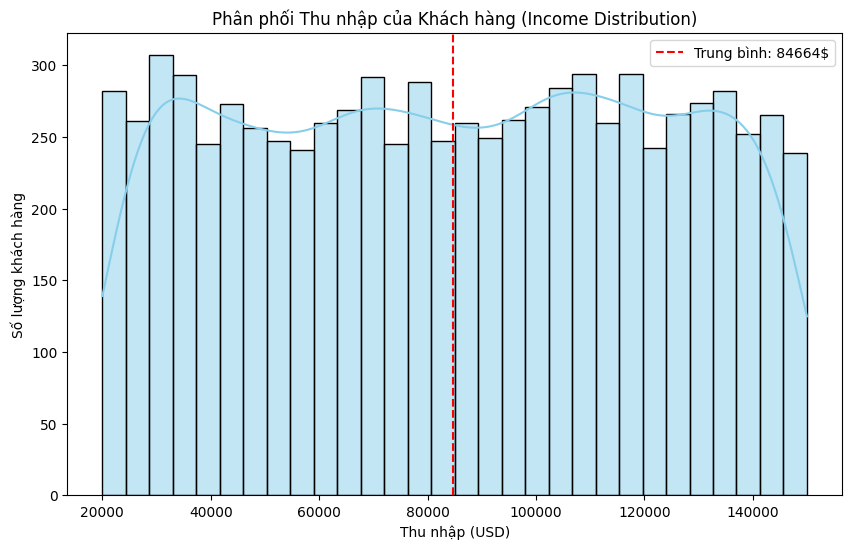

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Income'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Income'].mean():.0f}$")
plt.title('Phân phối Thu nhập của Khách hàng (Income Distribution)')
plt.xlabel('Thu nhập (USD)')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

<Axes: xlabel='Income', ylabel='Density'>

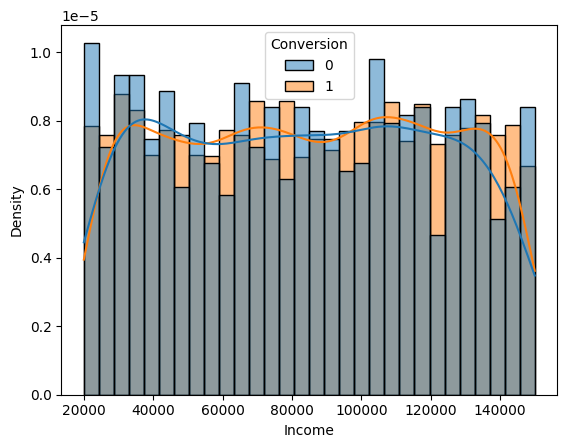

In [ ]:
sns.histplot(
    data=df,
    x="Income",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

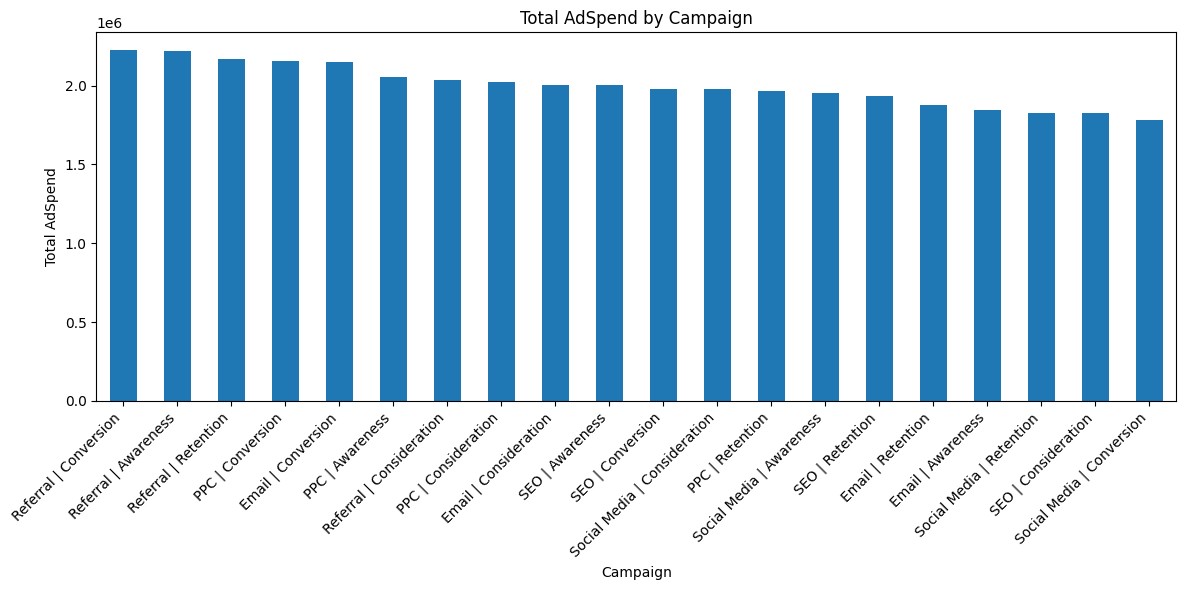

In [101]:
# Tạo campaign proxy
df["campaign"] = df["CampaignChannel"] + " | " + df["CampaignType"]

# Tổng AdSpend theo campaign
campaign_spend = (
    df.groupby("campaign")["AdSpend"]
      .sum()
      .sort_values(ascending=False)
)

# Plot distribution
plt.figure(figsize=(12,6))

campaign_spend.plot(kind="bar")

plt.title("Total AdSpend by Campaign")
plt.ylabel("Total AdSpend")
plt.xlabel("Campaign")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

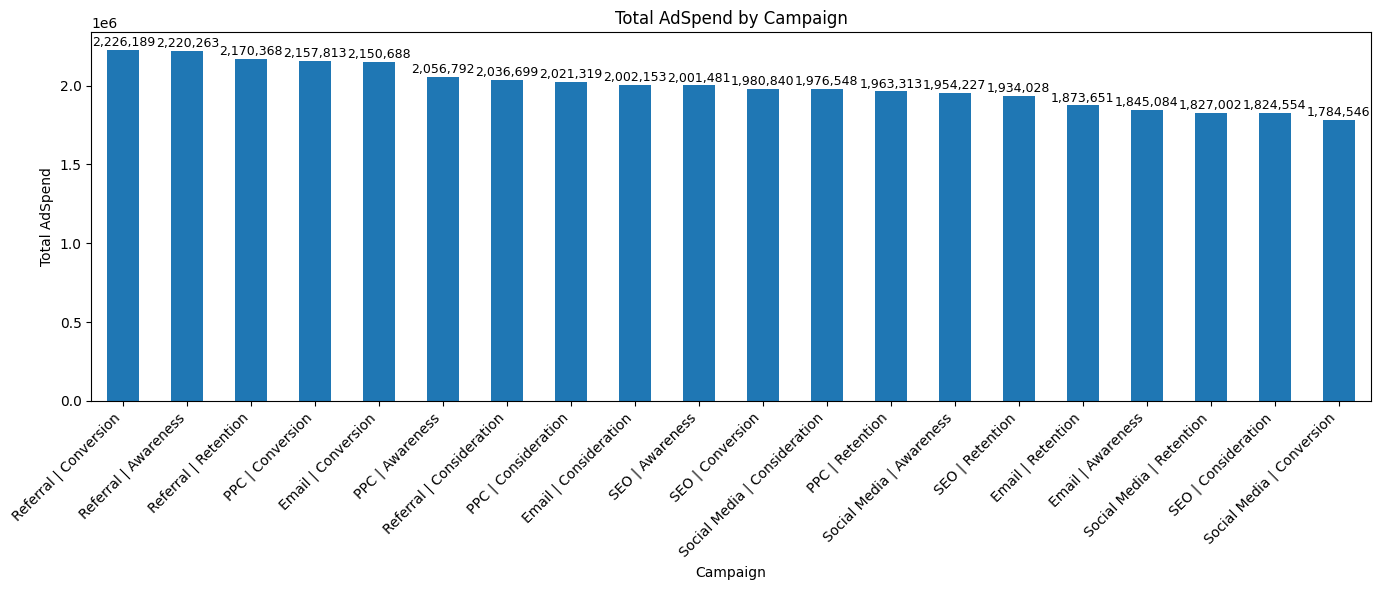

In [103]:
# Tạo campaign proxy
df["campaign"] = df["CampaignChannel"] + " | " + df["CampaignType"]

# Tổng AdSpend theo campaign
campaign_spend = (
    df.groupby("campaign")["AdSpend"]
      .sum()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(14,6))

ax = campaign_spend.plot(kind="bar")

# Hiện số trên đầu cột
for i, value in enumerate(campaign_spend):
    ax.text(
        i,
        value + 5000,          # đẩy chữ lên chút
        f'{value:,.0f}',       # bỏ số thập phân
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Total AdSpend by Campaign")
plt.ylabel("Total AdSpend")
plt.xlabel("Campaign")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Those Quantitative / Numerical and Conversion**

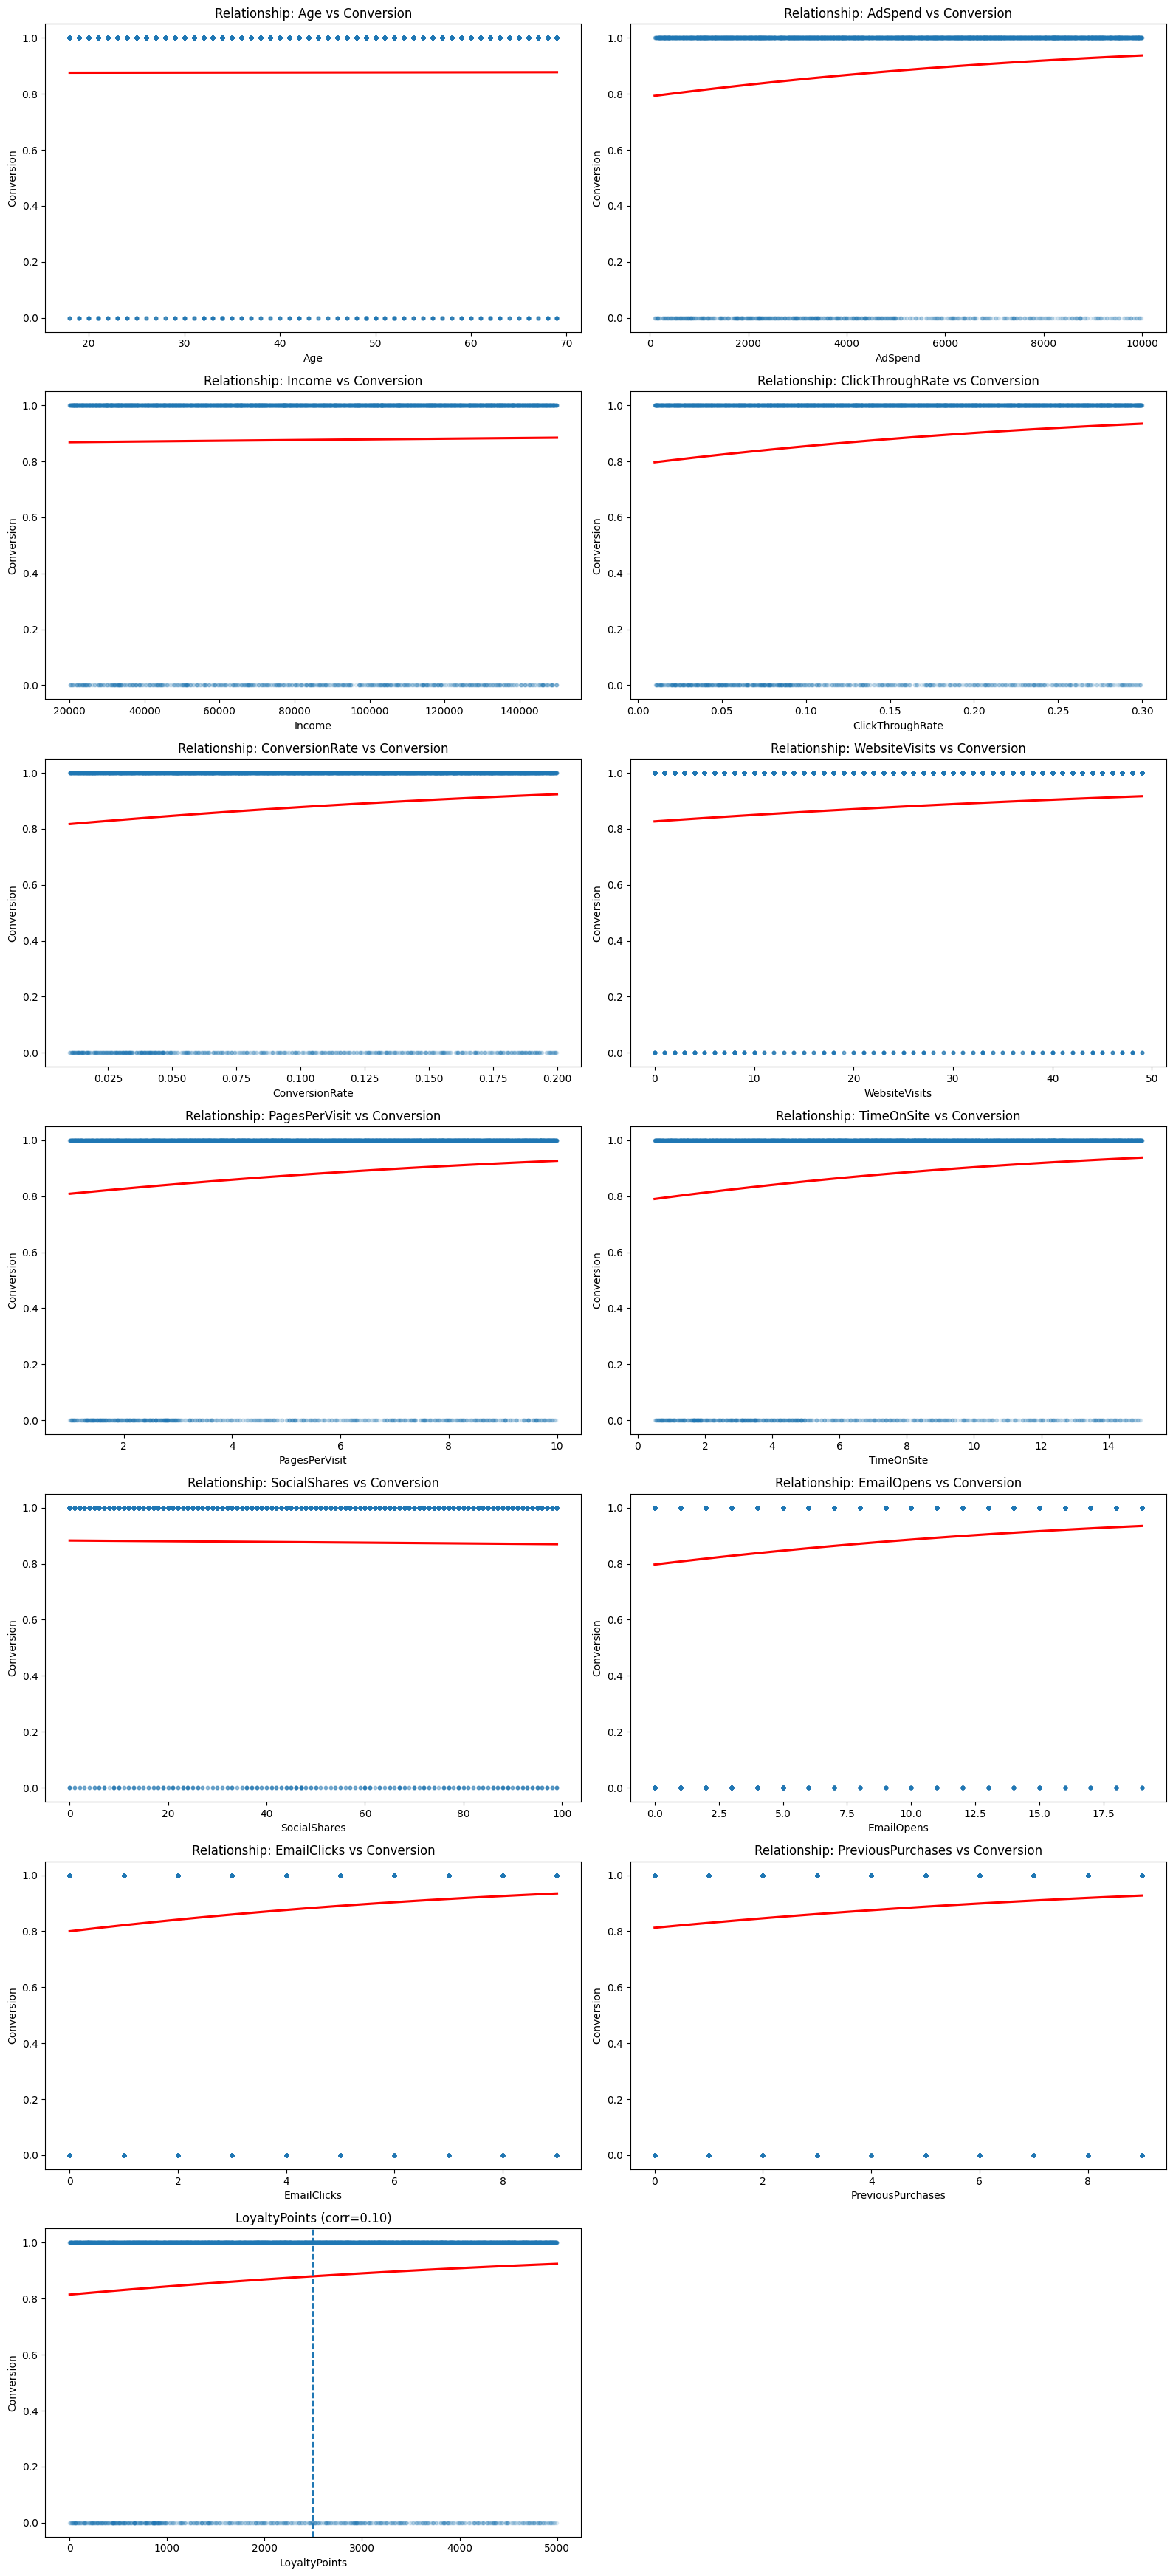

In [ ]:
numeric_cols = [
    'Age','AdSpend','Income','ClickThroughRate', 'ConversionRate', 'WebsiteVisits',
    'PagesPerVisit', 'TimeOnSite', 'SocialShares',
    'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints'
]
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
df_plot = df.copy()
df_plot['Conversion'] = df_plot['Conversion'].astype(float)

for i, col in enumerate(numeric_cols):

    sns.regplot(x=col, y='Conversion', data=df_plot,
                logistic=True, ci=None,
                scatter_kws={'alpha':0.1, 's':10},
                line_kws={'color':'red'}, ax=axes[i])

    axes[i].set_title(f'Relationship: {col} vs Conversion')
    axes[i].set_ylim(-0.05, 1.05)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# for i, col in enumerate(numeric_cols):
#     sns.regplot(
#         x=col, y='Conversion', data=df_plot,
#         logistic=True, ci=None,
#         scatter_kws={'alpha':0.1, 's':10},
#         line_kws={'color':'red'}, ax=axes[i]
#     )

    corr_value = df_plot[col].corr(df_plot['Conversion'])
    median_val = df_plot[col].median()

    axes[i].axvline(median_val, linestyle='--')
    axes[i].set_title(f'{col} (corr={corr_value:.2f})')
plt.tight_layout()
plt.show()

Most numerical features show weak individual correlations with conversion (ranging from ~0.08 to 0.13), indicating that no single variable strongly drives customer conversion.

Behavioral features such as engagement (time on site, pages per visit), interaction (click-through rate, email clicks), and purchase history (previous purchases, loyalty points) exhibit a positive but modest relationship with conversion.

In contrast, demographic variables like age and income show little to no impact. Additionally, social shares do not appear to translate into actual purchasing behavior.

Overall, conversion is driven by a combination of multiple factors rather than any single dominant feature.

Customer conversion is influenced by cumulative engagement signals rather than any single dominant feature

In [ ]:
for i, col in enumerate(numeric_cols):
    sns.regplot(
        x=col, y='Conversion', data=df_plot,
        logistic=True, ci=None,
        scatter_kws={'alpha':0.1, 's':10},
        line_kws={'color':'red'}, ax=axes[i]
    )

    corr_value = df_plot[col].corr(df_plot['Conversion'])
    median_val = df_plot[col].median()

    axes[i].axvline(median_val, linestyle='--')
    axes[i].set_title(f'{col} (corr={corr_value:.2f})')

### Dummies Category

In [ ]:
df_model = pd.get_dummies(df, drop_first=True)

In [ ]:
df_model.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,Conversion_1
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,688,False,False,False,False,True,False,False,False,True
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,3459,True,False,False,False,False,False,False,True,True
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,2337,False,True,False,False,False,False,False,False,True
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,2463,False,True,False,False,False,False,True,False,True
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,4345,False,True,False,False,False,False,True,False,True


## **MACHINE LEARNING**





### Build model

In [ ]:
# Drop các columns bị leak hoặc không có ý nghĩa predictive thực tế


drop_cols = [
    'Conversion_1',    # target
    'ConversionRate',  # leakage
    'Gender_Male',     # no signal
    'Age',             # no signal
    'Income',         # no signal
    'SocialShares',   # no signal
    'WebsiteVisits'   # no signal
]

X = df_model.drop(columns=drop_cols)
y = df_model['Conversion_1']

### Split Data 80:20

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [95]:
y_prob = model.predict_proba(X_test)[:, 1]

### AUC

In [96]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

np.float64(0.7703875878048422)

In [97]:
comparison = pd.DataFrame({
    'Thực tế (Y)': y_test,
    'Xác suất dự báo (P-convert)': y_prob
})
print(comparison.head(20))

      Thực tế (Y)  Xác suất dự báo (P-convert)
2215        False                     0.856090
2582         True                     0.863861
1662         True                     0.696043
3027         True                     0.977135
4343         True                     0.885688
2680        False                     0.875462
1765         True                     0.957922
1123         True                     0.820049
4054        False                     0.761076
3761         True                     0.982093
1535         True                     0.972537
2944         True                     0.890469
2987        False                     0.768100
4291         True                     0.958533
4342         True                     0.866622
4424        False                     0.491602
7941         True                     0.906182
4997         True                     0.990668
2748         True                     0.573407
2302         True                     0.984535


## **Calibration**

In [ ]:
# calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=10)
# calibrated_model.fit(X_train, y_train)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

base_model = LogisticRegression(max_iter=3000, solver='saga')  # saga converge tốt hơn lbfgs
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=10)
calibrated_model.fit(X_train_scaled, y_train)

y_prob_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Before:", y_prob[:5])
print("After :", y_prob_calibrated[:5])

Before: [0.85433042 0.8612848  0.66701681 0.9812094  0.84932611]
After : [0.85504059 0.86286959 0.70117207 0.9747253  0.88448139]


###  **Plot Calibration Curve**

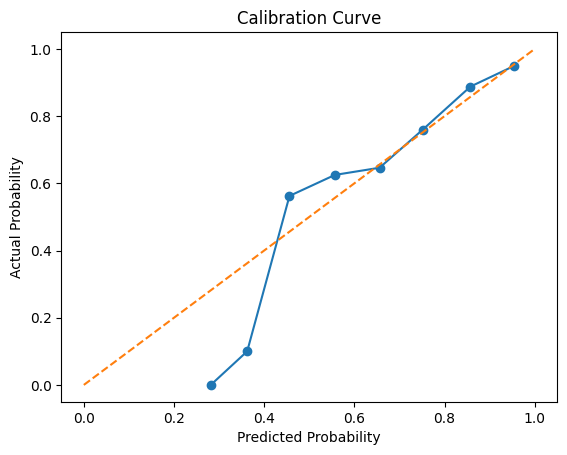

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')

plt.show()

The calibration curve indicates that predicted probabilities are generally aligned with observed outcomes, particularly in higher probability ranges. Minor deviations exist in lower probability segments, suggesting slight overestimation.

### **INSIGHT**

In [ ]:
# df_test = df.loc[X_test.index].copy()
# df_test["p_convert"] = y_prob_calibrated

# df_test["retention_months"] = df_test["PreviousPurchases"].replace(0, 1)
# df_test["monthly_revenue"]  = (df_test["Income"] * 0.05) / 12
# df_test["LTV"]              = df_test["monthly_revenue"] * df_test["retention_months"]

# CAC_LOW, CAC_HIGH = 50, 150
# df_test["EV_low"]  = df_test["p_convert"] * df_test["LTV"] - CAC_LOW
# df_test["EV_high"] = df_test["p_convert"] * df_test["LTV"] - CAC_HIGH

# df_test["segment"] = np.where(
#     (df_test["EV_low"] > 0) & (df_test["EV_high"] > 0), "KEEP", "CUT"
# )

# print(df_test["segment"].value_counts())
# print(df_test.groupby("segment")[["EV_low", "EV_high", "LTV", "p_convert"]].mean().round(2))

In [ ]:
# df_test = df.loc[X_test.index].copy()
# df_test["p_convert"] = y_prob_calibrated

# df_test["retention_months"] = df_test["PreviousPurchases"].replace(0, 1)
# df_test["monthly_revenue"]  = (df_test["Income"] * 0.05) / 12
# df_test["LTV"]              = df_test["monthly_revenue"] * df_test["retention_months"]

# # Dùng AdSpend làm cost
# df_test["EV"] = df_test["p_convert"] * df_test["LTV"] - df_test["AdSpend"]

# df_test["segment"] = np.where(df_test["EV"] > 0, "KEEP", "CUT")

# print(df_test["segment"].value_counts())
# print(df_test.groupby("segment")[["EV", "LTV", "AdSpend", "p_convert"]].mean().round(2))

In [ ]:
df_test = df.loc[X_test.index].copy()
df_test["p_convert"] = y_prob_calibrated

df_test["retention_months"] = df_test["PreviousPurchases"].replace(0, 1)
df_test["monthly_revenue"]  = (df_test["Income"] * 0.05) / 12
df_test["LTV"]              = df_test["monthly_revenue"] * df_test["retention_months"]

CAC_LOW, CAC_HIGH = 50, 150
df_test["EV_low"]  = df_test["p_convert"] * df_test["LTV"] - CAC_LOW
df_test["EV_high"] = df_test["p_convert"] * df_test["LTV"] - CAC_HIGH

# Group by campaign
campaign_ev = df_test.groupby("CampaignChannel").agg(
    n_customers   = ("EV_low", "count"),
    mean_EV_low   = ("EV_low", "mean"),
    mean_EV_high  = ("EV_high", "mean"),
    mean_LTV      = ("LTV", "mean"),
    mean_p_convert= ("p_convert", "mean")
).round(2)

print(campaign_ev.sort_values("mean_EV_low"))

# Group by CampaignType cũng làm tương tự
campaign_type_ev = df_test.groupby("CampaignType").agg(
    n_customers   = ("EV_low", "count"),
    mean_EV_low   = ("EV_low", "mean"),
    mean_EV_high  = ("EV_high", "mean"),
    mean_p_convert= ("p_convert", "mean")
).round(2)

print(campaign_type_ev.sort_values("mean_EV_low"))
print()

                 n_customers  mean_EV_low  mean_EV_high  mean_LTV  \
CampaignChannel                                                     
Referral                 349      1332.25       1232.25   1544.27   
PPC                      351      1362.71       1262.71   1590.64   
Email                    300      1364.84       1264.84   1572.16   
Social Media             313      1366.52       1266.52   1599.85   
SEO                      287      1366.90       1266.90   1569.84   

                 mean_p_convert  
CampaignChannel                  
Referral                   0.88  
PPC                        0.87  
Email                      0.87  
Social Media               0.87  
SEO                        0.88  
               n_customers  mean_EV_low  mean_EV_high  mean_p_convert
CampaignType                                                         
Awareness              385      1297.90       1197.90            0.86
Consideration          394      1297.94       1197.94            0.8

In [ ]:
# Tạo "campaign" = Channel + Type
df_test["campaign"] = df_test["CampaignChannel"] + " | " + df_test["CampaignType"]

campaign_ev = df_test.groupby("campaign").agg(
    n_customers    = ("EV_low", "count"),
    mean_EV_low    = ("EV_low", "mean"),
    mean_EV_high   = ("EV_high", "mean"),
    mean_LTV       = ("LTV", "mean"),
    mean_p_convert = ("p_convert", "mean"),
    total_adspend  = ("AdSpend", "sum")   # để estimate budget nếu cần
).round(2).sort_values("mean_EV_low")

print(campaign_ev)

                              n_customers  mean_EV_low  mean_EV_high  \
campaign                                                               
PPC | Retention                        82      1063.29        963.29   
Referral | Awareness                   71      1098.45        998.45   
Email | Awareness                      76      1129.82       1029.82   
Social Media | Consideration           85      1150.08       1050.08   
SEO | Retention                        79      1185.29       1085.29   
Social Media | Retention               67      1289.05       1189.05   
PPC | Consideration                    85      1291.27       1191.27   
SEO | Consideration                    61      1315.63       1215.63   
Referral | Conversion                  86      1328.64       1228.64   
Email | Consideration                  74      1334.57       1234.57   
Referral | Consideration               89      1402.96       1302.96   
PPC | Awareness                        91      1405.04       130

In [ ]:
# 1. EV framework — chỉ cho Conversion + Retention
ev_campaigns = df_test[
    df_test["CampaignType"].isin(["Conversion", "Retention"])
].groupby(["CampaignChannel", "CampaignType"])[["EV_low", "EV_high"]].mean()

# 2. Engagement metrics — cho Awareness + Consideration
top_funnel = df_test[
    df_test["CampaignType"].isin(["Awareness", "Consideration"])
].groupby(["CampaignChannel", "CampaignType"])[
    ["TimeOnSite", "PagesPerVisit", "EmailClicks"]
].mean()

# 3. Sensitivity table
for cac in [50, 100, 150]:
    n = (df_test["p_convert"] * df_test["LTV"] - cac > 0).sum()
    print(f"CAC=${cac}: {n} customers positive EV")

CAC=$50: 1597 customers positive EV
CAC=$100: 1557 customers positive EV
CAC=$150: 1514 customers positive EV
